Set Dataset Paths

In [1]:
import os

# Correct path from your screenshot
DATASET_ROOT = "/content/drive/MyDrive/CEDER_Final"

# Users are numbered like: 151, 152, ...
USER_DIRS = sorted([d for d in os.listdir(DATASET_ROOT)
                    if os.path.isdir(os.path.join(DATASET_ROOT, d))])

print("Users found:", USER_DIRS[:5], "... total =", len(USER_DIRS))


Users found: ['151', '152', '153', '154', '155'] ... total = 55


Preprocessing Function

In [2]:
import cv2
import numpy as np

IMG_SIZE = 220

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("❌ Could not load:", path)
        return None

    # Otsu binarization
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert: signature = white, background = black
    binary = 255 - binary

    # Resize with aspect ratio
    h, w = binary.shape
    scale = IMG_SIZE / max(h, w)
    resized = cv2.resize(binary, (int(w * scale), int(h * scale)))

    # Pad to square
    padded = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    y_off = (IMG_SIZE - resized.shape[0]) // 2
    x_off = (IMG_SIZE - resized.shape[1]) // 2
    padded[y_off:y_off+resized.shape[0], x_off:x_off+resized.shape[1]] = resized

    # Normalize
    padded = padded.astype(np.float32) / 255.0

    return padded


Preprocess + Cache

In [3]:
import json
from tqdm import tqdm

CACHE_DIR = "/content/cedar_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def preprocess_and_cache():
    cache_file = os.path.join(CACHE_DIR, "cedar_preprocessed.npy")
    index_file = os.path.join(CACHE_DIR, "cedar_index.json")

    # Load from cache
    if os.path.exists(cache_file) and os.path.exists(index_file):
        print("Loaded preprocessed dataset from cache.")
        return np.load(cache_file), json.load(open(index_file))

    data = []
    index_map = []

    for user in tqdm(USER_DIRS, desc="Preprocessing users"):
        user_path = os.path.join(DATASET_ROOT, user)

        gen_dir = os.path.join(user_path, "genuine")
        forg_dir = os.path.join(user_path, "forged")

        if not os.path.exists(gen_dir) or not os.path.exists(forg_dir):
            print("❌ Missing folder for user", user)
            continue

        gen_files = sorted([f for f in os.listdir(gen_dir) if f.lower().endswith(".png")])
        forg_files = sorted([f for f in os.listdir(forg_dir) if f.lower().endswith(".png")])

        for fname in gen_files:
            path = os.path.join(gen_dir, fname)
            img = preprocess_image(path)
            if img is None:
                continue
            data.append(img)
            index_map.append({"user": user, "file": fname, "type": "genuine"})

        for fname in forg_files:
            path = os.path.join(forg_dir, fname)
            img = preprocess_image(path)
            if img is None:
                continue
            data.append(img)
            index_map.append({"user": user, "file": fname, "type": "forgery"})

    data = np.array(data)
    np.save(cache_file, data)
    json.dump(index_map, open(index_file, "w"))
    print("Saved dataset to cache.")

    return data, index_map


data, index_map = preprocess_and_cache()
print("Preprocessed dataset shape:", data.shape)
print("Index entries:", len(index_map))


Preprocessing users: 100%|██████████| 55/55 [16:17<00:00, 17.77s/it]


Saved dataset to cache.
Preprocessed dataset shape: (2640, 220, 220)
Index entries: 2640


Build Pair Dataset

In [4]:
import random

def build_pairs(index_map, data):
    pairs = []
    labels = []

    # Group images by user
    user_dict = {}
    for i, info in enumerate(index_map):
        user_dict.setdefault(info["user"], []).append((i, info))

    for user, entries in user_dict.items():
        genuine_idx = [i for (i, info) in entries if info["type"] == "genuine"]
        forgery_idx = [i for (i, info) in entries if info["type"] == "forgery"]

        # genuine–genuine (positive)
        for a in genuine_idx:
            b = random.choice(genuine_idx)
            pairs.append((a, b))
            labels.append(1)

        # genuine–forgery (negative)
        for a in genuine_idx:
            b = random.choice(forgery_idx)
            pairs.append((a, b))
            labels.append(0)

    return pairs, labels


pairs, labels = build_pairs(index_map, data)
print("Total pairs:", len(pairs))


Total pairs: 2640


PyTorch Dataset

In [5]:
import torch
from torch.utils.data import Dataset

class SiameseDataset(Dataset):
    def __init__(self, pairs, labels, data):
        self.pairs = pairs
        self.labels = labels
        self.data = data

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        a, b = self.pairs[idx]
        img1 = self.data[a][None, :, :]  # (1, H, W)
        img2 = self.data[b][None, :, :]
        label = torch.tensor(self.labels[idx]).float()
        return torch.tensor(img1), torch.tensor(img2), label


Siamese Network

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class SiameseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(1, 32, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((10,10))
        )
        self.fc = nn.Sequential(
            nn.Linear(128*10*10, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward_once(self, x):
        x = self.feature(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

    def forward(self, x1, x2):
        f1 = self.forward_once(x1)
        f2 = self.forward_once(x2)
        return f1, f2


Contrastive Loss

In [7]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, f1, f2, label):
        dist = F.pairwise_distance(f1, f2)
        loss = label * dist.pow(2) + (1 - label) * F.relu(self.margin - dist).pow(2)
        return loss.mean()


Training Loop

In [8]:
from torch.utils.data import DataLoader
import torch.optim as optim

dataset = SiameseDataset(pairs, labels, data)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

model = SiameseCNN().cuda()
criterion = ContrastiveLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10):
    total_loss = 0
    for img1, img2, y in loader:
        img1 = img1.cuda()
        img2 = img2.cuda()
        y = y.cuda()

        f1, f2 = model(img1, img2)
        loss = criterion(f1, f2, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss = {total_loss/len(loader):.4f}")


Epoch 1, Loss = 0.2361
Epoch 2, Loss = 0.1698
Epoch 3, Loss = 0.1371
Epoch 4, Loss = 0.1051
Epoch 5, Loss = 0.0907
Epoch 6, Loss = 0.0789
Epoch 7, Loss = 0.0716
Epoch 8, Loss = 0.0645
Epoch 9, Loss = 0.0598
Epoch 10, Loss = 0.0544


Testing Function

In [9]:
def similarity(img1, img2):
    model.eval()
    with torch.no_grad():
        img1 = torch.tensor(img1).unsqueeze(0).unsqueeze(0).cuda()
        img2 = torch.tensor(img2).unsqueeze(0).unsqueeze(0).cuda()
        f1, f2 = model(img1, img2)
        dist = F.pairwise_distance(f1, f2).item()
    return dist


Compute Distance for All Pairs

In [10]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

model.eval()

all_distances = []
all_labels = []

with torch.no_grad():
    for img1, img2, y in tqdm(loader, desc="Evaluating"):
        img1 = img1.cuda()
        img2 = img2.cuda()

        f1, f2 = model(img1, img2)
        dist = F.pairwise_distance(f1, f2)

        all_distances.extend(dist.cpu().numpy())
        all_labels.extend(y.numpy())

all_distances = np.array(all_distances)
all_labels = np.array(all_labels)

print("Distances shape:", all_distances.shape)
print("Labels shape:", all_labels.shape)


Evaluating: 100%|██████████| 83/83 [00:03<00:00, 20.98it/s]

Distances shape: (2640,)
Labels shape: (2640,)


Choose Best Threshold & Compute Accuracy

In [23]:
from sklearn.metrics import accuracy_score, recall_score

def evaluate_threshold(distances, labels):
    thresholds = np.linspace(0, 2.0, 200)
    best_th, best_acc = None, 0

    for th in thresholds:
        preds = (distances < th).astype(int)
        acc = accuracy_score(labels, preds)
        if acc > best_acc:
            best_acc = acc
            best_th = th

    return best_th, best_acc


best_th_val, best_acc_val = evaluate_threshold(val_distances, val_labels)

preds_val = (val_distances < best_th_val).astype(int)

tp_val = np.sum((preds_val == 1) & (val_labels == 1))
tn_val = np.sum((preds_val == 0) & (val_labels == 0))
fp_val = np.sum((preds_val == 1) & (val_labels == 0))
fn_val = np.sum((preds_val == 0) & (val_labels == 1))

sensitivity_val = tp_val / (tp_val + fn_val + 1e-8)   # True Positive Rate
specificity_val = tn_val / (tn_val + fp_val + 1e-8)   # True Negative Rate

print(f"Validation Best Threshold = {best_th_val:.4f}")
print(f"Validation Accuracy = {best_acc_val*100:.2f}%")
print(f"Validation Sensitivity (TPR) = {sensitivity_val*100:.2f}%")
print(f"Validation Specificity (TNR) = {specificity_val*100:.2f}%")

Validation Best Threshold = 0.5327
Validation Accuracy = 96.59%
Validation Sensitivity (TPR) = 95.04%
Validation Specificity (TNR) = 98.12%


Plot Distance Distributions

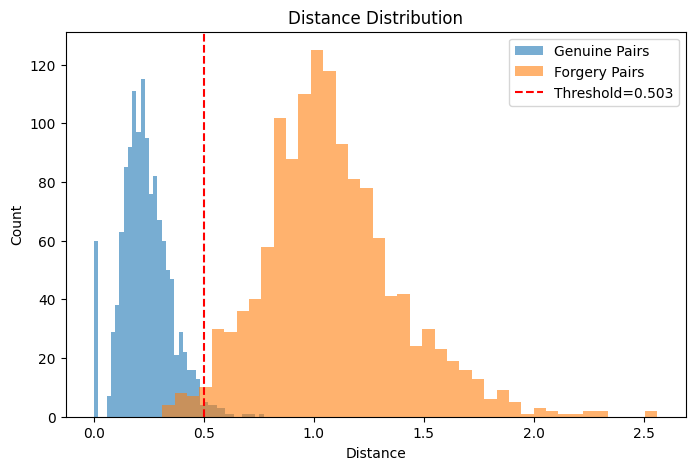

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(all_distances[all_labels == 1], bins=40, alpha=0.6, label="Genuine Pairs")
plt.hist(all_distances[all_labels == 0], bins=40, alpha=0.6, label="Forgery Pairs")
plt.axvline(best_th, color='red', linestyle='--', label=f"Threshold={best_th:.3f}")
plt.title("Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.legend()
plt.show()


ROC Curve + AUC

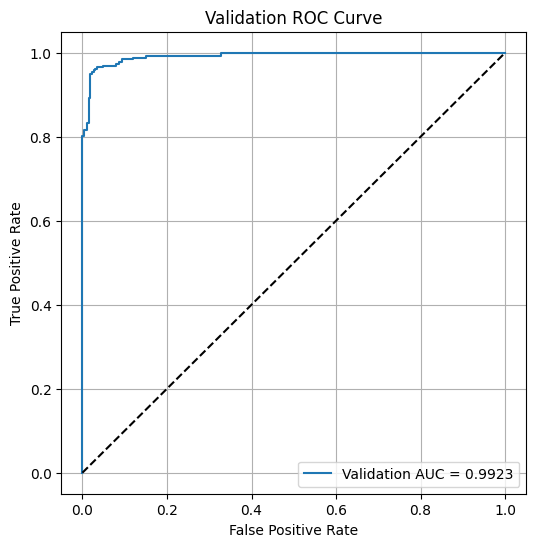

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(val_labels, -val_distances)  # negative because lower = genuine
auc_score_val = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Validation AUC = {auc_score_val:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("Validation ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix

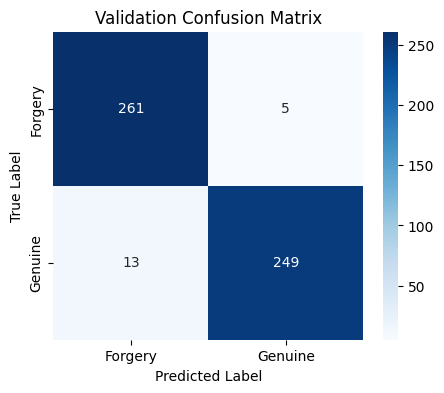

Validation Confusion Matrix:
[[261   5]
 [ 13 249]]


In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert distances to binary predictions using best threshold from validation set
preds_val_cm = (val_distances < best_th_val).astype(int)

# Compute confusion matrix
cm_val = confusion_matrix(val_labels, preds_val_cm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Forgery", "Genuine"],
            yticklabels=["Forgery", "Genuine"])

plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Validation Confusion Matrix:")
print(cm_val)


In [17]:
from torch.utils.data import DataLoader, random_split
import torch

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assuming `dataset` is already defined from previous cells
# (e.g., dataset = SiameseDataset(pairs, labels, data))

# Split the dataset into training and validation sets
train_size = int(0.8 * len(dataset)) # 80% for training
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create data loaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Assuming model, criterion, and optimizer are already defined and moved to device
model.to(device)

history = {
    "train_loss": [],
    "val_loss": []
}

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_losses = []

    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.float().to(device)

        optimizer.zero_grad()
        out1, out2 = model(img1, img2)
        loss = criterion(out1, out2, label)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    # ---- VALIDATION ----
    model.eval()
    val_losses = []

    with torch.no_grad():
        for img1, img2, label in val_loader:
            img1, img2, label = img1.to(device), img2.to(device), label.float().to(device)
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, label)
            val_losses.append(loss.item())

    avg_val_loss = sum(val_losses) / len(val_losses)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")


Epoch 1/20, Train Loss=0.0493, Val Loss=0.0486
Epoch 2/20, Train Loss=0.0452, Val Loss=0.0538
Epoch 3/20, Train Loss=0.0404, Val Loss=0.0561
Epoch 4/20, Train Loss=0.0399, Val Loss=0.0568
Epoch 5/20, Train Loss=0.0345, Val Loss=0.0532
Epoch 6/20, Train Loss=0.0316, Val Loss=0.0570
Epoch 7/20, Train Loss=0.0303, Val Loss=0.0532
Epoch 8/20, Train Loss=0.0267, Val Loss=0.0555
Epoch 9/20, Train Loss=0.0249, Val Loss=0.0535
Epoch 10/20, Train Loss=0.0236, Val Loss=0.0563
Epoch 11/20, Train Loss=0.0227, Val Loss=0.0579
Epoch 12/20, Train Loss=0.0203, Val Loss=0.0555
Epoch 13/20, Train Loss=0.0188, Val Loss=0.0546
Epoch 14/20, Train Loss=0.0171, Val Loss=0.0562
Epoch 15/20, Train Loss=0.0156, Val Loss=0.0581
Epoch 16/20, Train Loss=0.0149, Val Loss=0.0554
Epoch 17/20, Train Loss=0.0133, Val Loss=0.0569
Epoch 18/20, Train Loss=0.0128, Val Loss=0.0532
Epoch 19/20, Train Loss=0.0117, Val Loss=0.0549
Epoch 20/20, Train Loss=0.0113, Val Loss=0.0543


Plot Training vs Validation Loss

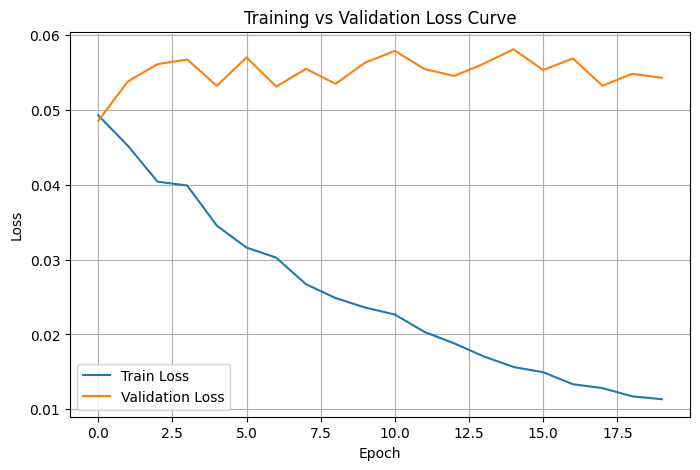

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

Compute Train & Test Distances

In [21]:
import torch
import numpy as np

def compute_distances(model, loader):
    model.eval()
    distances = []
    labels = []

    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            dist = torch.nn.functional.pairwise_distance(out1, out2)
            distances.extend(dist.cpu().numpy())
            labels.extend(label.numpy())

    return np.array(distances), np.array(labels)

train_distances, train_labels = compute_distances(model, train_loader)
val_distances, val_labels = compute_distances(model, val_loader)


Compute Train vs Test ROC-AUC

In [29]:
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(train_labels, -train_distances) # Negate distances for correct AUC
test_auc = roc_auc_score(val_labels, -val_distances) # Negate distances for correct AUC

print("Train AUC:", train_auc)
print("Test AUC :", test_auc)
print("AUC difference:", abs(train_auc - test_auc))


Train AUC: 1.0
Test AUC : 0.9922803191184066
AUC difference: 0.00771968088159336


Confusion Matrix

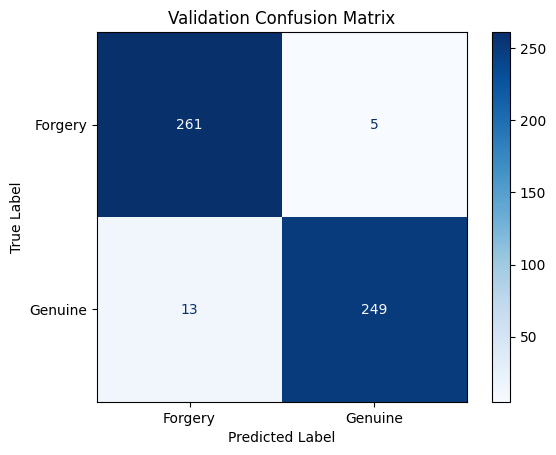

Validation Confusion Matrix:
[[261   5]
 [ 13 249]]


In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# We will use the best threshold determined from the validation set (best_th_val)
# and the validation distances/labels.
threshold = best_th_val # Use the best_th_val found earlier

y_pred = (val_distances < threshold).astype(int) # Use val_distances
cm = confusion_matrix(val_labels, y_pred) # Use val_labels

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Forgery", "Genuine"])
disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Validation Confusion Matrix:")
print(cm)
